In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

os.chdir("../")
print("Current work path:", os.getcwd())

Current work path: /home/pengxy2024/ICLR2026


In [ ]:
rb_path = "experiments/data/intro_various_budget/intro_rb_(4000,14001,2000).json"
sprout_path = "experiments/data/intro_various_budget/intro_sprout(400,1601,100).json"
rb_data = json.load(open(rb_path, 'r'))
sprout_data = json.load(open(sprout_path, 'r'))

lambdas = [0.1, 0.14, 0.18, 0.22, 0.24]
mus = [0.99, 0.95, 0.9, 0.8, 0.7]


In [3]:
def general_beautify(ax):
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_facecolor('white')
    ax.margins(0.02)


colorset = [[84 / 255, 111 / 255, 198 / 255],  
            [145 / 255, 203 / 255, 116 / 255], 
            [250 / 255, 200 / 255, 89 / 255], 
            [238 / 255, 102 / 255, 102 / 255],
            [115 / 255, 192 / 255, 222 / 255],
            [59 / 255, 163 / 255, 114 / 255], 
            [252 / 255, 132 / 255, 82 / 255], 
            [154 / 255, 96 / 255, 180 / 255], 
            # [142 / 255, 51 / 255, 138 / 255],
            ]

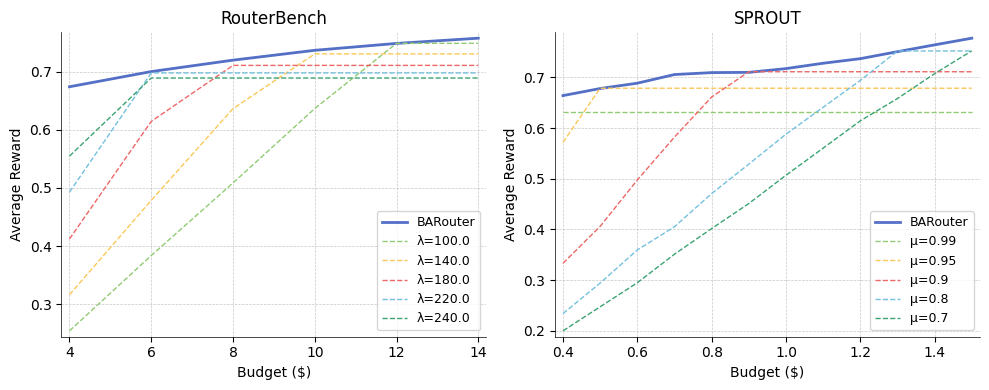

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax in axs:
    general_beautify(ax)

rb_x = list(range(4000, 14001, 2000))
rb_x = [x / 1000 for x in rb_x]
axs[0].plot(rb_x, rb_data['ours'], label='BARouter', color=colorset[0], linewidth=2)
for i, lam in enumerate(lambdas):
    axs[0].plot(rb_x, rb_data[f'google_knn_rb_lambda{lam}'], label=f'λ={lam * 1000}', color=colorset[i + 1], linestyle='--', linewidth=1)
axs[0].set_xlabel('Budget ($)')
axs[0].set_ylabel('Average Reward')
axs[0].legend(loc='lower right', fontsize=9)
axs[0].set_title('RouterBench', fontsize=12)

sprout_x = list(range(400, 1600, 100))
sprout_x = [x / 1000 for x in sprout_x]
axs[1].plot(sprout_x, sprout_data['ours'], label='BARouter', color=colorset[0], linewidth=2)
for i, mu in enumerate(mus):
    axs[1].plot(sprout_x, sprout_data[f'carrot_sprout_mu={mu}'], label=f'μ={mu}', color=colorset[i + 1], linestyle='--', linewidth=1)
axs[1].set_xlabel('Budget ($)')
axs[1].set_ylabel('Average Reward')
axs[1].legend(loc='lower right', fontsize=9)
axs[1].set_title('SPROUT', fontsize=12)

plt.tight_layout()
plt.savefig('img/budget_aware_intro.pdf', format='pdf', bbox_inches='tight')
plt.show()